In [ ]:
from util import * 
import matplotlib.pyplot as plt 
from numpy import sin, pi 

## Title 
$$ y = f(x)$$

Corrcoef: 0.811222


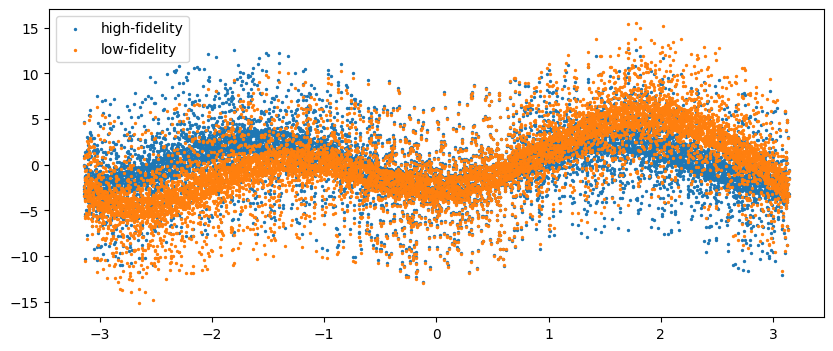

In [ ]:
# Ishigami Test Function
a,b = 5.0, 0.1
funcs = [
    lambda x: sin(x[0]) + a*sin(x[1])**2 + b*x[2]**4*sin(x[0])-2.3649892596024378, # High-fidelity 
    lambda x: funcs[0](x) + x[1]**2*sin(x[1])-0.1509850080368724 # Low-Fidelity
]

funcs_jax = [
    lambda x: jnp.sin(x[0]) + a*jnp.sin(x[1])**2 + b*x[2]**4*jnp.sin(x[0])-2.3649892596024378, # High-fidelity
    lambda x: funcs_jax[0](x) + x[1]**2*jnp.sin(x[1])-0.1509850080368724 # Low-Fidelity
]

# funcs = [
#     lambda x: sin(x[0]) + a*sin(x[1])**2 + b*x[2]**4*sin(x[0]) -2.5635013909329536, # High-fidelity 
#     lambda x: sin(x[0]) + 0.95*a*sin(x[1])**2 + b*x[2]**4*sin(x[0]) -2.3979439332660704# Low-Fidelity
# ]

# Assigning sample sizes
N_hi, N_lo, N_test = 80, 250, 10000
# Assigning computational budgets 
C_hi, C_lo = 1, 0.2
X_hi = np.random.uniform(-pi,pi, size=(3, N_hi))
X_lo = np.random.uniform(-pi,pi, size=(3, N_lo))
X_test = np.random.uniform(-pi,pi, size=(3,N_test))

# Centering Functions
Y_hi = funcs[0](X_hi) 
Y_lo = funcs[1](X_lo)

corr_coef = np.corrcoef(funcs[0](X_test), funcs[1](X_test))[0,1]

print("Corrcoef: %.6f" % corr_coef)

plt.figure(figsize=(10,4))
plt.scatter(X_test[1,:], funcs[0](X_test), s=2,label = "high-fidelity")
plt.scatter(X_test[1,:], funcs[1](X_test), s=2,label = "low-fidelity")
plt.legend()

In [3]:
np.mean(funcs[0](X_test)), np.mean(funcs[1](X_test))

(0.12444532643771879, -0.044096083094909186)

In [6]:
g1 = GP(
    X_lo.T,
    Y_lo, 
    RBF, 
    Linear, 
    max_cond = 1e8,
    noise_var = 1e-7, 
    epsilon = 1e-8,
    calibrate=True
)

g1.set_params(
    {'noise_var': jnp.array(-11.45490084), 
     'k_param':   jnp.array([707.20446669,  10.63440899,   7.49853734,  11.84757804]),
     'm_param':   jnp.array([ 2.97752426, -2.11667778, -4.71075235,  0.36777759])}
)

Calibrated white noise variance: 2.4900e-05


In [8]:
optimizer = ADAM(g1, neg_mll, beta1=0.95, beta2=0.9999)
optimizer.run(lr=8e-1, epochs=1000, params=['k_param', 'm_param', 'noise_var'])

100%|██████████| 1000/1000 [00:04<00:00, 220.83it/s, Loss: 9.3012e+01]


helo


{'noise_var': Array(-12.20176476, dtype=float64, weak_type=True),
 'k_param': Array([707.20446669,  12.91222799,   7.63959668,  11.59577407], dtype=float64),
 'm_param': Array([ 3.67421079, -0.79594984, -4.1114118 , -2.24590807], dtype=float64)}

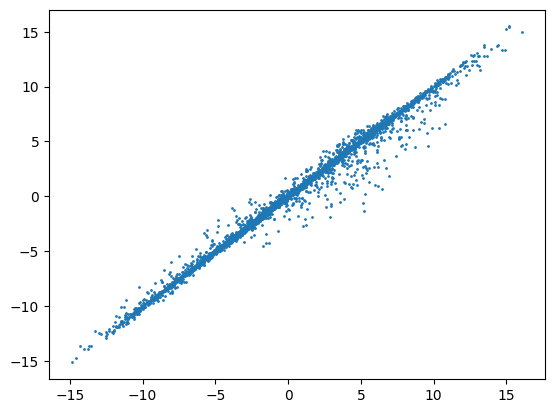

In [12]:
yhat_lo = g1.predict(X_test.T, full_cov=False)[0]
plt.scatter(yhat_lo, funcs[1](X_test), s = 1.0)

In [13]:
g0 = DeltaGP(
    X_hi.T,
    Y_hi, 
    g1.predict(X_hi.T, full_cov=False)[0], 
    RBF, 
    Zero, 
    noise_var = 1e-4, 
    epsilon = 1e-8, 
    max_cond = 1e5
)

g0.set_params(
    {'noise_var': jnp.array(-4.42980423), 
    'k_param':    jnp.array([  9.73185295, 148.63303317,   2.71150524, 280.83709397]),
    'm_param':    jnp.array([0., 0., 0.]), 
    'rho':        jnp.array(1.00197636)}
)

Calibrated white noise variance: 1.6549e-03


In [191]:
optimizer = ADAM(g0, delta_neg_mll, beta1=0.95, beta2=0.999)
optimizer.run(lr=5e-1, epochs=1000, params=['rho', 'k_param', 'm_param'])

100%|██████████| 1000/1000 [00:05<00:00, 198.07it/s, Loss: -1.6518e+02]


{'noise_var': Array(-4.42980423, dtype=float64, weak_type=True),
 'k_param': Array([ 12.81483564, 216.17933515,   2.76172073, 375.7117432 ], dtype=float64),
 'm_param': Array([0., 0., 0.], dtype=float64),
 'rho': Array(1.00307107, dtype=float64, weak_type=True)}

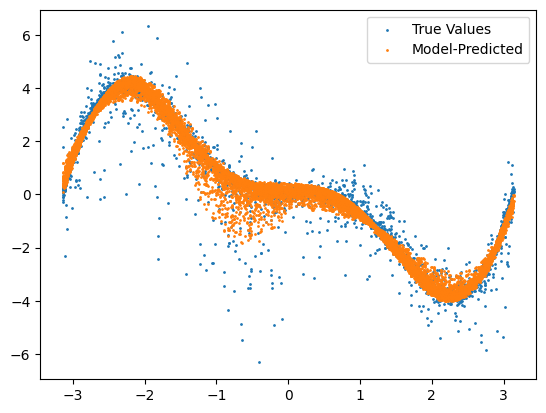

In [14]:
delta_mean = g0.predict(X_test.T, full_cov=False)[0]
yhat_hi = g0.p['rho'] * g1.predict(X_test.T, full_cov=False)[0] + delta_mean
plt.scatter(X_test[1,:], funcs[0](X_test) - g1.predict(X_test.T, full_cov=False)[0], s = 1.0, label = "True Values")
plt.scatter(X_test[1,:], delta_mean, s = 1.0, label = "Model-Predicted")
plt.legend()

In [15]:
kr = GP(
    X_hi.T,
    funcs[0](X_hi), 
    RBF, 
    Linear, 
    noise_var = 1e-8, 
    epsilon = 1e-12, 
    max_cond = 1e8
)
# kr.set_params(
#     {'noise_var':jnp.array(-13.46455067),
#     'k_param':   jnp.array([ 8.77047402, -2.59487462]),
#     'm_param':   jnp.array([-1.13692191,  5.07544546])}
# ) 
optimizer = ADAM(kr, neg_mll, beta1 = 0.9, beta2 = 0.999)
optimizer.run(lr = 5e-1, epochs = 5000, params = ['k_param', 'm_param'])

Calibrated white noise variance: 1.0000e-08


100%|██████████| 5000/5000 [00:11<00:00, 434.00it/s, Loss: 1.6736e+02]


helo


{'noise_var': Array(-18.42068075, dtype=float64, weak_type=True),
 'k_param': Array([20.82172214,  6.59357532,  3.05014902,  4.63104646], dtype=float64),
 'm_param': Array([ 0.19964532,  0.80309479, -0.08523402, -0.22668727], dtype=float64)}

In [16]:
delta_mean, delta_var = g0.predict(X_test.T, full_cov = False)
lo_mean, lo_var = g1.predict(X_test.T, full_cov = False)
rho = g0.p['rho']

mean = rho * lo_mean + delta_mean 
var = rho**2 * lo_var + delta_var 
conf = 2 * np.sqrt(var)

kr_mean, kr_var = kr.predict(X_test.T, full_cov = False)
kr_conf = 2 * np.sqrt(kr_var)
print("Multifidelity: %.4e" % np.mean(var + (mean - funcs[0](X_test))**2))
print("Kriging:       %.4e" % np.mean(var + (kr_mean - funcs[0](X_test))**2))

Multifidelity: 1.8683e-01
Kriging:       2.6718e+00


100%|██████████| 12/12 [09:46<00:00, 48.86s/it]


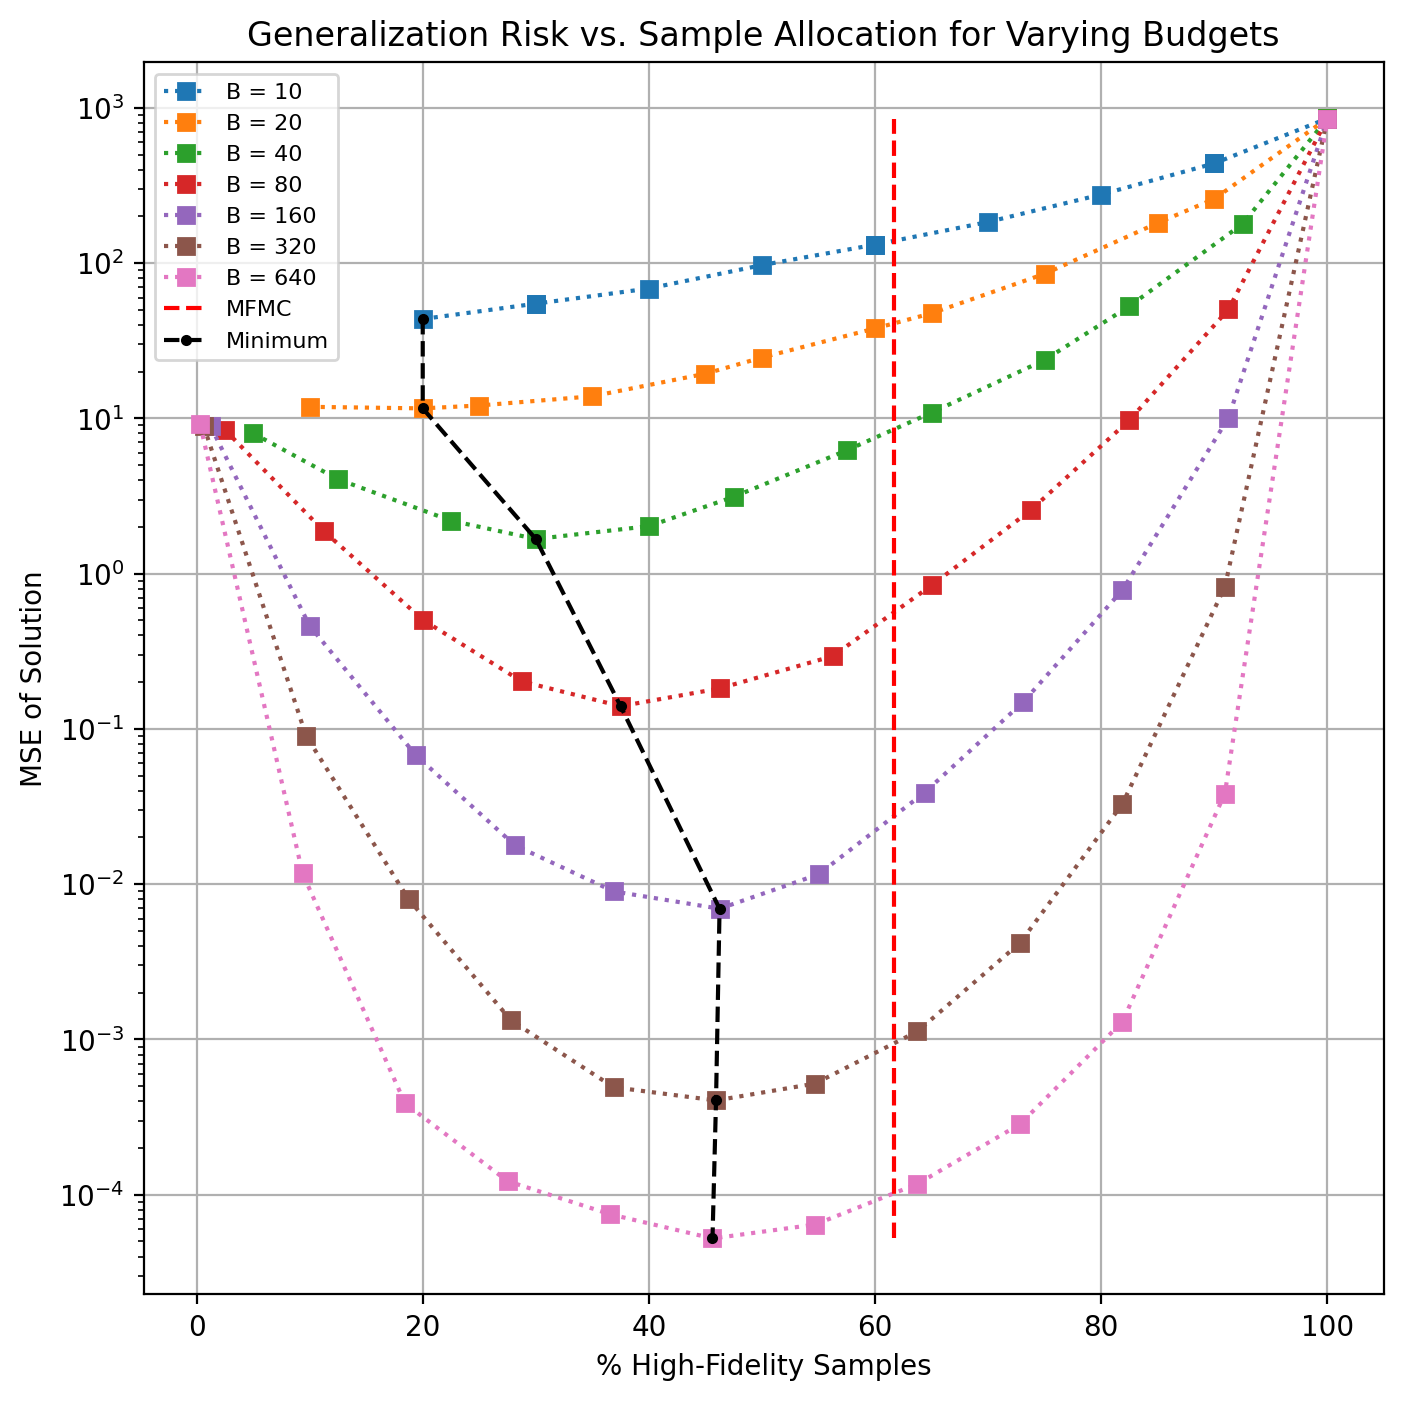

In [18]:
def get_mse(g0, g1, X_hi, X_lo, X_test):
    Y_hi = funcs_jax[0](X_hi.T)
    Y_lo = funcs_jax[1](X_lo.T)

    # Low-fidelity predictions
    Ktrain = K(X_lo, X_lo, g1.kernel, g1.p['k_param']) + (g1.eps + softplus(g1.p['noise_var'])) * jnp.eye(X_lo.shape[0])
    L = cholesky(Ktrain, lower=True)
    alpha = cho_solve((L, True), Y_lo - g1.mean.eval(X_lo, g1.p['m_param']))
    Ktest = K(X_test, X_lo, g1.kernel, g1.p['k_param'])
    lo_mean = (Ktest @ alpha + g1.mean.eval(X_test, g1.p['m_param'])).ravel()
    Kaux = (jax.vmap(lambda x: g1.kernel.eval(x, x, g1.p['k_param']))(X_test)).ravel()
    lo_var = Kaux - jnp.diag(Ktest @ cho_solve((L, True), Ktest.T))

    # High-fidelity predictions
    Y_hi_lo = funcs_jax[1](X_hi.T)
    rho = g0.p['rho']
    Ktrain = K(X_hi, X_hi, g0.kernel, g0.p['k_param']) + (g0.eps + softplus(g1.p['noise_var'])) * jnp.eye(X_hi.shape[0])
    L = cholesky(Ktrain, lower=True)
    alpha = cho_solve((L, True), (Y_hi - rho * Y_hi_lo))
    Ktest = K(X_test, X_hi, g0.kernel, g0.p['k_param'])
    delta_mean = (Ktest @ alpha + g0.mean.eval(X_test, g0.p['m_param'])).ravel()
    Kaux = (jax.vmap(lambda x: g0.kernel.eval(x, x, g0.p['k_param']))(X_test)).ravel()
    delta_var = Kaux - jnp.diag(Ktest @ cho_solve((L, True), Ktest.T))

    mean = rho * lo_mean + delta_mean
    var = rho**2 * lo_var + delta_var

    return jnp.mean(var + (mean - funcs[0](X_test.T))**2)

get_mse_jit = jax.jit(lambda X_hi, X_lo: get_mse(g0, g1, X_hi, X_lo, X_test.T))

# MFMC Budget Allocation for two levels of fidelity
c11, c22, c12 = np.var(funcs[0](X_test)), np.var(funcs[1](X_test)), np.cov(np.vstack((funcs[0](X_test).reshape(1,-1), funcs[1](X_test).reshape(1,-1))))[0,1]
alpha = c12 / c22 
ratio = np.sqrt(C_hi  / C_lo * corr_coef**2 / (1 - corr_coef**2))

N_mc = 15
key = jax.random.PRNGKey(41)
N_budgets = 7
budget = 10

min_Ns, min_mses = [], []

plt.figure(figsize=(8,8), dpi = 200)

for i in (range(N_budgets)):
    # Allocating N_his and N_los 
    N_hi_min, N_hi_max = 2, int(budget / C_hi)
    N_his = jnp.arange(N_hi_min, N_hi_max+1)
    
    if len(N_his > 12):
        N_his = jnp.round(jnp.linspace(2, int(budget / C_hi), 12))
    
    N_los = jnp.floor((budget - N_his * C_hi) / C_lo)
    N_lo_max = jnp.max(N_los).astype(int)

    # Generate full arrays
    key_hi, key_lo = jax.random.split(key, 2)
    X_hi_full = jax.random.uniform(key_hi, minval=-pi, maxval=pi, shape=(N_mc, N_hi_max, 3))
    X_lo_full = jax.random.uniform(key_lo, minval=-pi, maxval=pi, shape=(N_mc, N_lo_max, 3))

    full_mses = np.zeros(N_his.shape[0])

    # Compute MSEs 
    for j, (N_hi, N_lo) in tqdm(enumerate(zip(N_his, N_los)), total = N_his.shape[0]):
        # Preallocate MSE array
        mses = np.zeros(N_mc)
        for k in range(N_mc):
            X_hi = X_hi_full[k, :int(N_hi), :]
            X_lo = X_lo_full[k, :int(N_lo), :]
            mse = get_mse_jit(X_hi, X_lo)
            mses[k] = mse
        
        full_mses[j] = np.mean(mses)

    # Computing optimal allocation
    N_hi_opt = budget / (C_lo * ratio + C_hi)
    N_lo_opt = ratio * N_hi_opt 

    min_idx = np.argmin(full_mses)
    min_Ns.append(N_his[min_idx] / np.max(N_his)*100)
    min_mses.append(full_mses[min_idx])

    # plt.subplot(1,N_budgets,i+1)
    plt.semilogy(N_his / np.max(N_his)*100, full_mses, label = "B = %d" % budget, linestyle = 'dotted', marker = 's')
    # plt.fill_between(N_his, results[:,0] - results[:,1], results[:,0] + results[:,1], alpha = 0.3, color = 'blue', label = 'two-sigma')

    # Doubling the budget 
    budget *= 2 

plt.plot([np.round(N_hi_opt)/ np.max(N_his)*100, np.round(N_hi_opt)/ np.max(N_his)*100], [min(full_mses), max(full_mses)], label = "MFMC", color = 'red', linestyle = 'dashed')
plt.plot(min_Ns, min_mses, marker = ".", color = 'black', linestyle = 'dashed', label = "Minimum")
plt.xlabel("% High-Fidelity Samples")
plt.ylabel("MSE of Solution")
plt.legend(loc = 'upper left', fontsize=8)
plt.title("Generalization Risk vs. Sample Allocation for Varying Budgets")
plt.grid()

In [24]:
N_his[min_idx]

Array(292., dtype=float64)

In [23]:
N_los[min_idx]

Array(1740., dtype=float64)

In [ ]:
full_mses

 20%|██        | 2/10 [01:55<07:43, 58.00s/it]


ValueError: setting an array element with a sequence.

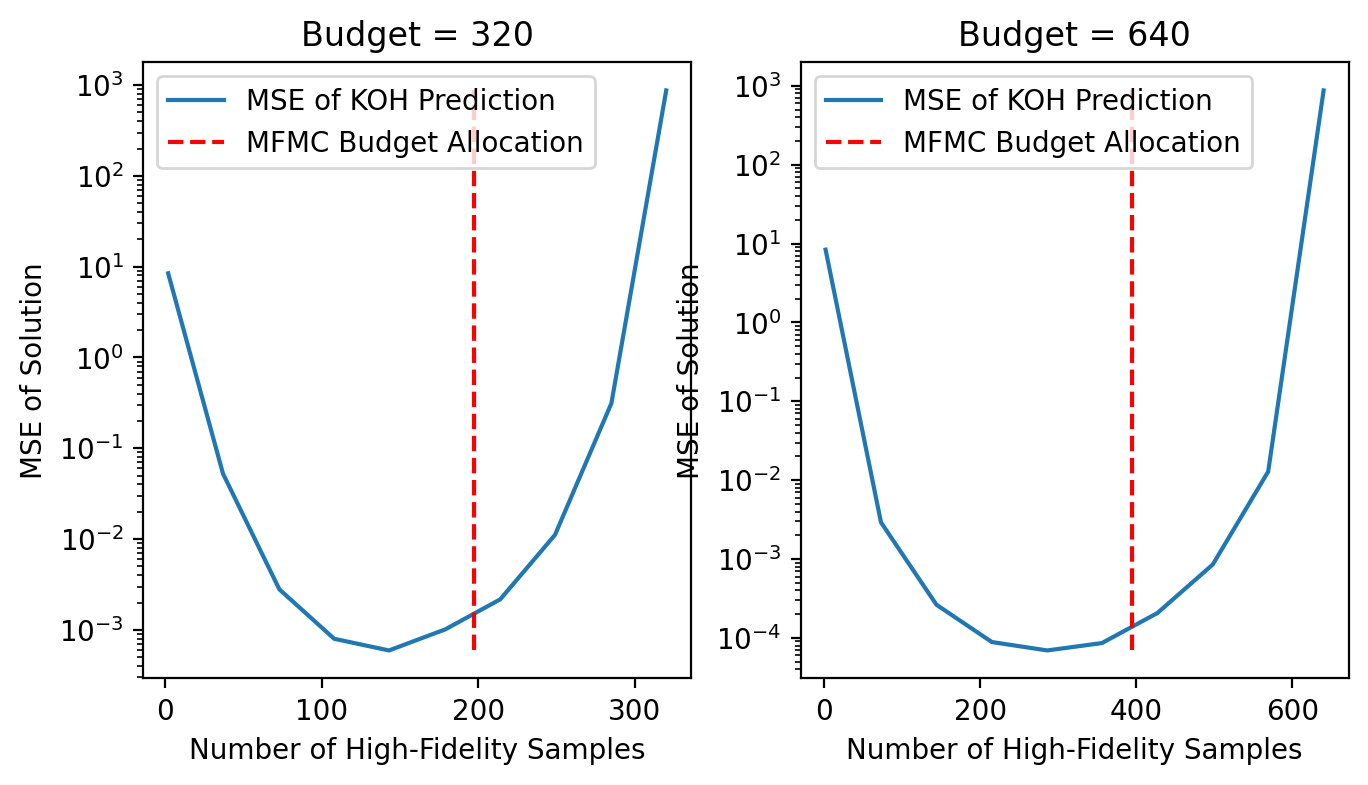

In [165]:
plt.figure(figsize=(N_budgets * 4.1,4), dpi = 200)

for i in (range(N_budgets)):
    # Allocating N_his and N_los 
    N_hi_min, N_hi_max = 2, int(budget / C_hi)
    N_his = jnp.arange(N_hi_min, N_hi_max+1)
    
    if len(N_his > 10):
        N_his = jnp.round(jnp.linspace(2, int(budget / C_hi), 10))
    
    N_los = jnp.floor((budget - N_his * C_hi) / C_lo)
    N_lo_max = jnp.max(N_los).astype(int)

    # Generate full arrays
    key_hi, key_lo = jax.random.split(key, 2)
    X_hi_full = jax.random.uniform(key_hi, minval=-pi, maxval=pi, shape=(N_mc, N_hi_max, 3))
    X_lo_full = jax.random.uniform(key_lo, minval=-pi, maxval=pi, shape=(N_mc, N_lo_max, 3))

    full_mses = np.zeros(N_his.shape[0])

    # Compute MSEs 
    for j, (N_hi, N_lo) in tqdm(enumerate(zip(N_his, N_los)), total = N_his.shape[0]):
        # Preallocate MSE array
        mses = np.zeros(N_mc)
        for k in range(N_mc):
            X_hi = X_hi_full[k, :int(N_hi), :]
            X_lo = X_lo_full[k, :int(N_lo), :]
            mse = get_mse_jit(X_hi, X_lo)
            mses[k] = mse
        
        full_mses[j] = np.mean(mses)

    # Computing optimal allocation
    N_hi_opt = budget / (C_lo * ratio + C_hi)
    N_lo_opt = ratio * N_hi_opt 

    plt.subplot(1,N_budgets,i+1)
    plt.semilogy(N_his, full_mses, label = "MSE of KOH Prediction")
    # plt.fill_between(N_his, results[:,0] - results[:,1], results[:,0] + results[:,1], alpha = 0.3, color = 'blue', label = 'two-sigma')
    plt.plot([np.round(N_hi_opt), np.round(N_hi_opt)], [min(full_mses), max(full_mses)], label = "MFMC Budget Allocation", color = 'red', linestyle = 'dashed')
    plt.xlabel("Number of High-Fidelity Samples")
    plt.ylabel("MSE of Solution")
    plt.legend()
    plt.title("Budget = %d" % budget)
    
    # Doubling the budget 
    budget *= 2 